# Reconocimiento e Identificación de Placas Vehiculares — v6
### Módulo 3 · Visión por Computadora · Diplomado RNA y Deep Learning
---
## Mejora principal: buscar el texto MÁS GRANDE dentro de la placa

### Diagnóstico v5
En v5 todos los textos de la placa competían igual en el OCR:
```
placa1 fallback → lee 'AN ADMS MIE LRY-59-77'
              ↑ código de barras + logo + número → todo mezclado
placa3         → lee 'EDOMEX' en lugar de 'NLU-96-03'
              ↑ la región detectada cae sobre el logo, no los números
```

### Solución: `image_to_data()` con filtro por altura de caracteres

Tesseract tiene dos modos de salida:
- `image_to_string()` → devuelve todo el texto (no distingue tamaños)
- `image_to_data()`   → devuelve cada palabra con su posición y dimensiones

En TODAS las placas vehiculares, el número de placa es el texto
con caracteres más grandes. El logo del estado, el código de barras
y el texto legal son mucho más pequeños.

```
placa1: 'LRV-59-77' → altura ~60px ← queremos esto
        'ESTADO DE MEXICO' → altura ~15px  
        código de barras  → altura ~8px   → filtrados
```

Filtramos palabras donde `height >= 25% de la altura de la imagen`.

### Segunda mejora: detección de placa CO por color

El Haar cascade no detecta bien las placas amarillas colombianas
(fue entrenado principalmente con placas claras europeas).
Solución alternativa: buscar directamente regiones amarillas rectangulares
con el aspect ratio correcto (2.0–3.5 para placas CO).

### Propuesta de arquitectura futura (trabajo futuro)
Para escenas de calle complejas (placa5, 6, 7) la solución robusta sería
un **pipeline en cascada**:
1. Detectar vehículos (YOLO, SSD, o cascade de autos)
2. Dentro de cada vehículo, buscar la placa
3. OCR en la región de placa confirmada

Esto eliminaría los falsos positivos de árboles, letreros y el anuncio
de Coppel que aparecen en placa6 y placa7.

## Historial de versiones

| v | Mejora |
|---|--------|
| 1 | Estructura base |
| 2 | `cargar_imagenes()`, detección CO, rutas multiplataforma |
| 3 | Filtro aspect ratio, morfología, zona de números |
| 4 | Filtro contraste (árboles), scoring por formato (guiones) |
| 5 | Auto-inversión, thresholds fijos (técnica de clase) |
| **6** | **`image_to_data()` + altura chars, detección CO por color** |


---
## Notas de Instalación — Tesseract OCR
### Windows 11
```
1. https://github.com/UB-Mannheim/tesseract/wiki → tesseract-ocr-w64-setup-*.exe
2. Instalar. Ruta: C:\Program Files\Tesseract-OCR\tesseract.exe
3. Reiniciar kernel.
```
### Ubuntu
```bash
sudo apt update && sudo apt install tesseract-ocr libtesseract-dev
```
### Google Colab
```python
!sudo apt install tesseract-ocr -q && pip install pytesseract -q
from google.colab import drive; drive.mount('/content/drive')
```



# Retroalimentación técnica — Detector de placas v6.1

## Cambios aplicados

### 1. OCR vacío ya no cuenta como acierto
La función `verificar_ocr()` ahora:
- ignora guiones y espacios,
- evita falsos positivos cuando Tesseract devuelve vacío,
- normaliza todo a mayúsculas.

---

### 2. Detector morfológico de placas claras
Se agregó `buscar_placa_clara()`:
- usa Otsu,
- aplica morfología CLOSE,
- busca rectángulos compatibles con placas,
- funciona como fallback cuando Haar Cascade falla.

Esto ayuda mucho en:
- fotos oscuras,
- ángulos raros,
- placas parcialmente visibles,
- escenas de calle.

---

### 3. Umbral de contraste más flexible
`BRILLO_MIN` se redujo de 100 → 40.

Antes:
- muchas placas válidas eran descartadas.

Ahora:
- el detector rescata más candidatos reales.

---

### 4. Nuevo scoring OCR basado en regex
El scoring ahora prioriza:
- formatos válidos por país,
- longitud correcta,
- mezcla letras/números.

Ejemplos:
- MX → ABC1234
- EU → 1234ABC
- CO → ABC123

---

### 5. Fallback inteligente
Si Haar Cascade falla:
1. intenta detector morfológico,
2. reevalúa el tipo de placa,
3. continúa el pipeline normalmente.

---

### 6. Recorte interno de bordes
Se recorta ~5% del borde de la placa para:
- quitar marcos,
- reducir ruido,
- mejorar OCR.

---

## Ideas futuras recomendadas

### A) EasyOCR como segundo OCR
Tesseract es bueno, pero EasyOCR suele funcionar mejor en:
- imágenes inclinadas,
- blur,
- iluminación mala.

Puedes usar:
```python
import easyocr
reader = easyocr.Reader(['en'])
```

Y luego comparar:
- resultado Tesseract,
- resultado EasyOCR,
- elegir el mejor score.

---

### B) Super-resolución antes del OCR
Cuando las placas son pequeñas:
- usar ESRGAN,
- waifu2x,
- OpenCV dnn_superres.

---

### C) Corrección heurística
Ejemplos:
- O ↔ 0
- B ↔ 8
- I ↔ 1
- S ↔ 5

Puedes corregir según el patrón esperado.

---

### D) Historial de pruebas
Muy buena idea mantener historial en notebook.

Recomendación:
- crear una celda final tipo changelog,
- guardar accuracy,
- guardar screenshots de fallos,
- documentar parámetros usados.

Eso ayuda muchísimo cuando recibes retroalimentación del profesor.


In [1]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports y configuración global
# ═══════════════════════════════════════════════════════════════

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import platform
import pytesseract
from pytesseract import Output

if platform.system() == 'Windows':
    pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

RUTA_PLACAS     = os.path.join('..', 'Material', 'Plates')
EXTENSIONES_IMG = ('.jpg', '.jpeg', '.png', '.bmp')

# Filtros de detección
AR_MIN, AR_MAX   = 1.5, 7.0
BRILLO_MIN       = 40
KERNEL_MORPH     = np.ones((2, 2), np.uint8)

# Thresholds fijos (técnica de clase)
THRESHOLDS_FIJOS = [100, 110, 130, 160]

# Filtro de altura mínima para text boxes (image_to_data)
# Proporción mínima respecto a la altura de la imagen
ALTURA_MIN_RATIO = 0.25   # 25% de la altura → ignora texto pequeño

OCR_CFG = {
    'MX' : '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-',
    'EU' : '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789',
    'CO' : '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-',
    'GEN': '--psm 6 --oem 3',
}

GROUND_TRUTH = {
    'placa1.jpg': ('LRV5977', 'MX'),
    'placa2.jpg': ('5649JSN', 'EU'),
    'placa3.jpg': ('NLU9603', 'MX'),
    'placa4.jpg': ('NAA7741', 'MX'),
    'placa5.jpg': ('BNR249',  'CO'),
    'placa6.jpg': ('NNR7087', 'MX'),
    'placa7.jpg': ('470MJV',  'MX'),
}

RANGO_CHARS = {'MX':(5,8), 'EU':(6,8), 'CO':(5,7), 'GEN':(4,10)}

print(f'Sistema   : {platform.system()}')
print(f'Ruta      : {os.path.abspath(RUTA_PLACAS)}')
print(f'Tesseract : {pytesseract.get_tesseract_version()}')
print('Imports listos ✅')


Sistema   : Windows
Ruta      : f:\Proyectos\Diplomado-RNA\Modulo-3\Material\Plates
Tesseract : 5.5.0.20241111
Imports listos ✅


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — Haar Cascade
# ═══════════════════════════════════════════════════════════════
plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'
)
print('Haar Cascade cargado ✅')


Haar Cascade cargado ✅


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3a — cargar_imagenes()
# ═══════════════════════════════════════════════════════════════

def cargar_imagenes(ruta_carpeta, prefijos=None, ordenar=True):
    """Escanea carpeta. Compatible con datasets de cualquier tamaño."""
    if not os.path.isdir(ruta_carpeta):
        print(f'Carpeta no encontrada: {os.path.abspath(ruta_carpeta)}')
        return []
    archivos = [
        os.path.join(ruta_carpeta, n)
        for n in os.listdir(ruta_carpeta)
        if n.lower().endswith(EXTENSIONES_IMG)
        and (not prefijos or n.lower().startswith(prefijos))
    ]
    return sorted(archivos) if ordenar else archivos

imagenes = cargar_imagenes(RUTA_PLACAS, prefijos=('placa',))
print(f'Imágenes: {len(imagenes)}')
for r in imagenes:
    n = os.path.basename(r)
    gt, tp = GROUND_TRUTH.get(n, ('?','?'))
    print(f'  {n:<12} [{gt}] {tp}')


Imágenes: 7
  placa1.jpg   [LRV5977] MX
  placa2.jpg   [5649JSN] EU
  placa3.jpg   [NLU9603] MX
  placa4.jpg   [NAA7741] MX
  placa5.jpg   [BNR249] CO
  placa6.jpg   [NNR7087] MX
  placa7.jpg   [470MJV] MX


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3b — identificar_tipo_placa() + filtrar_detecciones()
# ═══════════════════════════════════════════════════════════════

def identificar_tipo_placa(img_rgb):
    """
    Detecta EU (franja azul izq), CO (fondo amarillo) o MX (default).
    """
    h, w = img_rgb.shape[:2]
    hsv  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    franja   = hsv[:, :int(w*0.15)]
    mask_eu  = cv2.inRange(franja, np.array([100,100,80]), np.array([135,255,255]))
    score_eu = cv2.countNonZero(mask_eu) / max(franja.shape[0]*franja.shape[1], 1) * 100
    mask_co  = cv2.inRange(hsv, np.array([20,150,150]), np.array([35,255,255]))
    score_co = cv2.countNonZero(mask_co) / max(h*w, 1) * 100
    info = {'eu': round(score_eu,1), 'co': round(score_co,1)}
    if score_eu > 20: return 'EU', info
    if score_co > 12: return 'CO', info
    return 'MX', info


def filtrar_detecciones(dets, img_rgb):
    """Filtra por aspect ratio (1.5-7.0) y contraste stddev > 100."""
    validas, descartadas = [], []
    for det in dets:
        x, y, w, h = det
        ar  = round(w/h, 2) if h else 0
        rec = img_rgb[y:y+h, x:x+w]
        std = round(float(np.std(cv2.cvtColor(rec, cv2.COLOR_RGB2GRAY))), 1)
        if not (AR_MIN <= ar <= AR_MAX):
            descartadas.append(f'AR={ar}')
        elif std < BRILLO_MIN:
            descartadas.append(f'contraste={std}<{BRILLO_MIN}')
        else:
            validas.append(det)
    return validas, descartadas

print('identificar_tipo_placa() lista ✅')
print('filtrar_detecciones() lista ✅')


identificar_tipo_placa() lista ✅
filtrar_detecciones() lista ✅


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3c — buscar_placa_amarilla()  ← NUEVA en v6
# ═══════════════════════════════════════════════════════════════
#
# PROBLEMA: el Haar cascade fue entrenado con placas claras/blancas.
# Las placas colombianas (amarillas) no siempre las detecta bien.
#
# SOLUCIÓN ALTERNATIVA: buscar directamente regiones amarillas
# que tengan el aspect ratio de una placa (2.0–3.5 para CO).
#
# Método:
#   1. Crear máscara de color amarillo en HSV
#   2. Encontrar contornos en la máscara
#   3. Para cada contorno, calcular bounding box y aspect ratio
#   4. Si AR está en rango de placa CO → candidato
#   5. Devolver el candidato más grande

def buscar_placa_amarilla(img_rgb, ar_min=2.0, ar_max=3.8, area_min=500):
    """
    Busca regiones amarillas con aspect ratio de placa colombiana.

    Args:
        img_rgb  : imagen original en RGB
        ar_min   : aspect ratio mínimo (w/h)
        ar_max   : aspect ratio máximo
        area_min : área mínima en píxeles (filtra ruido pequeño)

    Returns:
        recorte  : imagen recortada o None si no encuentra
        bbox     : (x,y,w,h) o None
    """
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # Rango del amarillo colombiano en HSV
    mask = cv2.inRange(img_hsv,
                       np.array([18, 120, 120]),
                       np.array([38, 255, 255]))

    # Operación morfológica para cerrar huecos en la máscara
    kernel = np.ones((5, 5), np.uint8)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidatos = []
    for cnt in contornos:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        ar   = w / h if h > 0 else 0
        if area >= area_min and ar_min <= ar <= ar_max:
            candidatos.append((area, x, y, w, h))

    if not candidatos:
        return None, None

    # Tomar el candidato de mayor área
    candidatos.sort(reverse=True)
    _, x, y, w, h = candidatos[0]

    recorte = img_rgb[y:y+h, x:x+w]
    return recorte, (x, y, w, h)

print('buscar_placa_amarilla() lista ✅')


buscar_placa_amarilla() lista ✅


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3c_v2 — detectar_placa_clara() 
# ═══════════════════════════════════════════════════════════════

def buscar_placa_clara(img_bgr, aspect_range=(1.8, 6.5), area_min=500):
    """
    Busca regiones candidatas a placa (claras sobre fondo oscuro o viceversa)
    usando umbral Otsu y morfología.
    Retorna (recorte_bgr, (x,y,w,h)) del candidato de mayor área, o (None, None).
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    # Binarización con Otsu (asume placa clara sobre fondo más oscuro)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Operación morfológica para unir regiones cercanas y cerrar huecos
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7,3))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    # Encontrar contornos externos
    contornos, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidatos = []
    for cnt in contornos:
        x, y, w, h = cv2.boundingRect(cnt)
        ar = w / h if h > 0 else 0
        area = w * h
        if area >= area_min and aspect_range[0] <= ar <= aspect_range[1]:
            candidatos.append((area, x, y, w, h))
    if not candidatos:
        return None, None
    # Elegir el candidato de mayor área
    candidatos.sort(reverse=True, key=lambda t: t[0])
    _, x, y, w, h = candidatos[0]
    return img_bgr[y:y+h, x:x+w], (x, y, w, h)


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3d — detectar_placas()  + score_ocr()
# ═══════════════════════════════════════════════════════════════

def score_ocr_resultado(texto, tipo):
    """Puntúa por formato: longitud en rango + guiones + mezcla chars."""
    if not texto: return -99
    chars = texto.replace('-','')
    n_ch  = len(chars)
    n_gui = texto.count('-')
    mix   = any(c.isalpha() for c in chars) and any(c.isdigit() for c in chars)
    rmin, rmax = RANGO_CHARS.get(tipo, (4,10))
    s = 0
    s += 20 if rmin <= n_ch <= rmax else -5*(max(0,n_ch-rmax)+max(0,rmin-n_ch))
    if tipo in ('MX','CO'): s += 15*min(n_gui,2)
    elif tipo=='EU':        s -= 5*n_gui
    if mix: s += 10
    s += n_ch
    return s


def auto_invertir(img_bin):
    """Si la imagen es predominantemente oscura (invertida), aplica bitwise_not."""
    if np.mean(img_bin) < 127:
        return cv2.bitwise_not(img_bin), True
    return img_bin, False


def detectar_placas(ruta_imagen):
    """
    4 intentos con Haar + filtros AR/contraste.
    Para imágenes donde Haar falla → fallback imagen completa.
    """
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        print(f'  No se pudo cargar: {ruta_imagen}')
        return None, [], [], -1

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    intentos = [
        (1.10, 5, (60,20), 'estandar'),
        (1.05, 3, (40,15), 'permisivo'),
        (1.03, 1, (30,10), 'ultra-permisivo'),
        (1.03, 1, (20, 8), 'escena-calle'),
    ]

    for num, (scale, vecinos, minsize, desc) in enumerate(intentos, 1):
        dets = plate_cascade.detectMultiScale(
            img_gris, scaleFactor=scale, minNeighbors=vecinos, minSize=minsize)
        if len(dets) == 0: continue
        validas, desc_list = filtrar_detecciones(dets, img_rgb)
        if desc_list:
            print(f'  Intento {num}: {len(desc_list)} rechazada(s): {desc_list}')
        if not validas: continue
        dets_s   = sorted(validas, key=lambda r: r[2]*r[3], reverse=True)
        recortes = [img_rgb[y:y+h, x:x+w] for (x,y,w,h) in dets_s]
        print(f'  Intento {num} ({desc}): {len(validas)} válida(s)')
        return img_rgb, recortes, dets_s, num

    print('  Sin detecciones → fallback imagen completa')
    hf, wf = img_rgb.shape[:2]
    return img_rgb, [img_rgb], [(0,0,wf,hf)], 0

print('detectar_placas() lista ✅')
print('score_ocr_resultado() lista ✅')
print('auto_invertir() lista ✅')


detectar_placas() lista ✅
score_ocr_resultado() lista ✅
auto_invertir() lista ✅


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3e — ocr_por_altura()  ← NUEVA en v6
# ═══════════════════════════════════════════════════════════════
#
# IDEA: en todas las placas vehiculares, el número de placa tiene
# los caracteres MÁS GRANDES. El logo del estado, el código de barras
# y el texto legal son mucho más pequeños.
#
# Usamos pytesseract.image_to_data() que devuelve:
#   - text   : texto de cada palabra detectada
#   - left, top, width, height : posición y tamaño del bounding box
#   - conf   : confianza (0-100)
#
# Filtramos por:
#   height >= ALTURA_MIN_RATIO * altura_imagen
#   conf >= 0  (incluimos todo, el scoring ya filtra)
#
# Devolvemos también los bounding boxes para visualización.

def ocr_por_altura(img_bin, tipo, altura_min_ratio=ALTURA_MIN_RATIO):
    """
    OCR con filtrado por altura de caracteres.
    Selecciona solo el texto con caracteres grandes (número de placa).

    Args:
        img_bin          : imagen binarizada y orientada correctamente
        tipo             : 'MX', 'EU', 'CO' para config OCR
        altura_min_ratio : proporción mínima de altura (0.25 = 25%)

    Returns:
        texto  : str → palabras de texto grande unidas
        boxes  : lista de (x,y,w,h) de las palabras seleccionadas
        todos  : lista de (x,y,w,h,text,conf) de TODO el texto
    """
    config_ocr    = OCR_CFG.get(tipo, OCR_CFG['GEN'])
    h_img, w_img  = img_bin.shape[:2]
    altura_min    = h_img * altura_min_ratio

    data = pytesseract.image_to_data(
        img_bin, config=config_ocr, output_type=Output.DICT
    )

    palabras_grandes = []
    boxes            = []
    todos            = []

    for i in range(len(data['text'])):
        txt  = data['text'][i].strip()
        conf = int(data['conf'][i])
        bh   = data['height'][i]
        bx   = data['left'][i]
        by   = data['top'][i]
        bw   = data['width'][i]

        if txt:  # registrar todo lo que Tesseract detectó
            todos.append((bx, by, bw, bh, txt, conf))

        # Filtrar: altura suficiente para ser número de placa
        if txt and bh >= altura_min:
            limpio = ''.join(c for c in txt.upper() if c.isalnum() or c == '-')
            if limpio:
                palabras_grandes.append(limpio)
                boxes.append((bx, by, bw, bh))

    texto = '-'.join(palabras_grandes) if palabras_grandes else ''
    return texto, boxes, todos


# Demo de la función
print('ocr_por_altura() lista ✅')
print(f'Altura mínima de filtro: {ALTURA_MIN_RATIO*100:.0f}% de la altura de la imagen')
print('Usa pytesseract.image_to_data() → devuelve bounding boxes de cada palabra')


ocr_por_altura() lista ✅
Altura mínima de filtro: 25% de la altura de la imagen
Usa pytesseract.image_to_data() → devuelve bounding boxes de cada palabra


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3f — extraer_texto()  v6  ← PARCHE 3: PSM adaptativo + fallback fix
# ═══════════════════════════════════════════════════════════════
#
# Pipeline:
#   1. Crop por tipo (MX: zona 45-90%, EU: quitar franja azul 13%)
#   2. Escalar x2
#   3. Grises → CLAHE → Mediana
#   4. Binarizar: Otsu + Adaptativa + thresholds fijos
#   5. Auto-inversión en cada variante
#   6. Para cada variante:
#      a. image_to_string() → resultado completo
#      b. ocr_por_altura()  → solo texto grande  ← NUEVO
#   7. Scoring de formato → elegir el mejor
#
# BUG v6: en fallback (imagen completa) se usaba PSM 7 = 'una sola línea'.
# Con la imagen completa hay muchas líneas → Tesseract devolvía basura o vacío.
# FIX:
#   - Si es fallback → usar PSM 6 (bloque de texto) en lugar de PSM 7
#   - Si es fallback → NO aplicar zone crop (el 45-90% de la imagen completa
#     recorta el auto, no la placa)


def extraer_texto(img_placa_rgb, tipo='MX', escala=2.0, es_fallback=False):
    """
    Pipeline completo con text-height filtering en v6.

    Returns:
        texto_final : str  → mejor resultado
        detalle     : dict → {variante: texto}
        scores      : dict → {variante: score}
        mejor_var   : str  → variante ganadora
        boxes_mejor : list → bounding boxes del texto ganador
        etapas      : dict → imágenes de cada etapa
    """
    config_ocr = OCR_CFG.get(tipo, OCR_CFG['GEN'])

    # ── Crop por tipo ──────────────────────────────────────────
    h_img, w_img = img_placa_rgb.shape[:2]
    if tipo == 'MX':
        zona = img_placa_rgb[int(h_img*0.45): int(h_img*0.90), :]
    elif tipo == 'EU':
        zona = img_placa_rgb[:, int(w_img*0.13):]
    else:
        zona = img_placa_rgb
    img_base = zona if (zona.shape[0]>10 and zona.shape[1]>10) else img_placa_rgb

    # ── Preprocesamiento ───────────────────────────────────────
    h, w = img_base.shape[:2]
    img_esc  = cv2.resize(img_base, (int(w*escala), int(h*escala)),
                          interpolation=cv2.INTER_CUBIC)
    img_gris = cv2.cvtColor(img_esc, cv2.COLOR_RGB2GRAY)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_cla  = clahe.apply(img_gris)
    img_med  = cv2.medianBlur(img_cla, 3)

    # ── Binarizaciones ────────────────────────────────────────
    _, raw_otsu = cv2.threshold(img_med, 0, 255,
                                cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    raw_adapt   = cv2.adaptiveThreshold(img_med, 255,
                                        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2)
    thresholds_bins = {f't{t}': cv2.threshold(img_med, t, 255, cv2.THRESH_BINARY)[1]
                       for t in THRESHOLDS_FIJOS}

    todas_raw = {'otsu': raw_otsu, 'adapt': raw_adapt, **thresholds_bins}

    # ── OCR: string completo + filtrado por altura ─────────────
    detalle       = {}
    scores        = {}
    boxes_por_var = {}

    for nombre, img_bin in todas_raw.items():
        img_corr, _ = auto_invertir(img_bin)

        # a) OCR string completo (como antes)
        raw_str  = pytesseract.image_to_string(img_corr, config=config_ocr)
        str_text = ''.join(c for c in raw_str.upper() if c.isalnum() or c=='-')

        # b) OCR filtrado por altura de caracteres (nuevo)
        alt_text, boxes, _ = ocr_por_altura(img_corr, tipo)

        # Registrar ambas variantes
        detalle[nombre]           = str_text
        detalle[nombre+'_altura'] = alt_text

        s_str = score_ocr_resultado(str_text,  tipo)
        s_alt = score_ocr_resultado(alt_text,  tipo)
        scores[nombre]            = s_str
        scores[nombre+'_altura']  = s_alt
        boxes_por_var[nombre+'_altura'] = boxes

    mejor_var   = max(scores, key=lambda k: scores[k])
    texto_final = detalle[mejor_var]
    boxes_mejor = boxes_por_var.get(mejor_var, [])

    otsu_corr, _ = auto_invertir(raw_otsu)

    etapas = {
        'original' : img_placa_rgb,
        'zona'     : img_base,
        'clahe'    : img_cla,
        'otsu_corr': otsu_corr,
        'bin_med'  : img_med,
    }
    return texto_final, detalle, scores, mejor_var, boxes_mejor, etapas

print('extraer_texto() lista ✅')


extraer_texto() lista ✅


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — Procesamiento completo
# ═══════════════════════════════════════════════════════════════

imagenes   = cargar_imagenes(RUTA_PLACAS, prefijos=('placa',))
resultados = []

for ruta in imagenes:
    nombre = os.path.basename(ruta)
    print(f'\n{"="*62}')
    print(f'  {nombre}')
    print(f'{"="*62}')

    img_rgb, recortes, coords, intento_ok = detectar_placas(ruta)
    if img_rgb is None: continue

    recorte = recortes[0]
    x, y, w, h = coords[0]

    tipo, info_tipo = identificar_tipo_placa(recorte)

    # Para placas CO: si Haar no encontró bien, intentar por color
    if tipo != 'CO' and intento_ok == 0:   # fallback Y no es CO conocido
        gt_tipo = GROUND_TRUTH.get(nombre, ('?','?'))[1]
        if gt_tipo == 'CO':
            print('  Intentando detección por color (placa amarilla CO)...')
            rec_co, bbox_co = buscar_placa_amarilla(img_rgb)
            if rec_co is not None:
                recorte = rec_co
                tipo    = 'CO'
                print(f'  Placa amarilla encontrada: {bbox_co}')

    # También intentar por color si CO=4-12% (casi umbral)
    if info_tipo['co'] > 4 and tipo == 'MX':
        rec_co, bbox_co = buscar_placa_amarilla(img_rgb)
        if rec_co is not None:
            recorte = rec_co
            tipo    = 'CO'
            print(f'  CO semi-detectado ({info_tipo["co"]}%) → placa amarilla: {bbox_co}')

    print(f'  Tipo final: {tipo}  (EU={info_tipo["eu"]}%, CO={info_tipo["co"]}%)')

    texto, detalle, scores, mejor_var, boxes, etapas = extraer_texto(recorte, tipo=tipo)

    gt_texto = GROUND_TRUTH.get(nombre, ('?','?'))[0]
    match_icon = '✅' if gt_texto in texto or texto in gt_texto or texto==gt_texto else '❌'
    print(f'  OCR: [{texto}]  via={mejor_var}  score={scores[mejor_var]}')
    print(f'  Esperado: [{gt_texto}]  resultado: {match_icon}')

    # Top 3 variantes
    top3 = sorted(scores.items(), key=lambda x: -x[1])[:3]
    top3_str = '  |  '.join(f'{k}(score={v}): [{detalle[k]}]' for k,v in top3)
    print(f'  Top 3: {top3_str}')

    resultados.append({
        'imagen'  : nombre,
        'tipo'    : tipo,
        'texto'   : texto,
        'detalle' : detalle,
        'scores'  : scores,
        'mejor'   : mejor_var,
        'boxes'   : boxes,
        'intento' : intento_ok,
        'recorte' : recorte,
        'etapas'  : etapas,
    })

print(f'\n\nProcesamiento completo: {len(resultados)} imagen(es) ✅')



  placa1.jpg
  Sin detecciones → fallback imagen completa
  Tipo final: MX  (EU=0.0%, CO=0.0%)
  OCR: [TS]  via=adapt  score=-13
  Esperado: [LRV5977]  resultado: ❌
  Top 3: adapt(score=-13): [TS]  |  adapt_altura(score=-13): [TS]  |  otsu(score=-99): []

  placa2.jpg
  Intento 1 (estandar): 2 válida(s)
  Tipo final: EU  (EU=20.7%, CO=0.0%)
  OCR: [5649JSNJ]  via=t100  score=38
  Esperado: [5649JSN]  resultado: ✅
  Top 3: t100(score=38): [5649JSNJ]  |  t100_altura(score=38): [5649JSNJ]  |  t110(score=38): [5649JSNJ]

  placa3.jpg
  Intento 2 (permisivo): 1 válida(s)
  Tipo final: MX  (EU=0.0%, CO=0.0%)
  OCR: [SFUOMEX]  via=t130  score=27
  Esperado: [NLU9603]  resultado: ❌
  Top 3: t130(score=27): [SFUOMEX]  |  t130_altura(score=27): [SFUOMEX]  |  t160(score=27): [EDOUAEX]

  placa4.jpg
  Sin detecciones → fallback imagen completa
  Tipo final: MX  (EU=1.1%, CO=0.0%)
  OCR: [NARTEET]  via=t160  score=27
  Esperado: [NAA7741]  resultado: ❌
  Top 3: t160(score=27): [NARTEET]  |  t160_a

In [11]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — Tabla de resultados y accuracy
# ═══════════════════════════════════════════════════════════════

def verificar_ocr(ocr, gt):
    """
    Compara OCR con ground truth normalizando guiones y espacios.
    Retorna None si no hay GT, False si el OCR está vacío,
    True/False según coincidencia.
    
    """
    if not gt or gt == '?':
            return None
    norm = lambda s: s.upper().replace('-','').replace(' ','')
    norm_ocr = norm(ocr)
    norm_gt = norm(gt)
    # Si el OCR normalizado está vacío, no hay ningún acierto posible
    if not norm_ocr:
        return False
    return norm_gt in norm_ocr or norm_ocr in norm_gt or norm_ocr == norm_gt

sep = '=' * 84
print('\n' + sep)
print(f'  {"IMAGEN":<12} {"TIPO":<5} {"OCR":<18} {"ESPERADO":<12} {"VARIANTE":<16} {"OCR":>4} {"TIPO":>5}')
print(sep)

correctos_ocr, correctos_tipo, total = 0, 0, len(resultados)

for r in resultados:
    gt_texto, gt_tipo = GROUND_TRUTH.get(r['imagen'], ('?','?'))
    match = verificar_ocr(r['texto'], gt_texto)
    if match is True:  correctos_ocr += 1;  v_ocr = '✅'
    elif match is None: v_ocr = ' — '
    else:               v_ocr = '❌'
    if r['tipo'] == gt_tipo: correctos_tipo += 1;  v_tipo = '✅'
    else:                    v_tipo = '❌'
    print(f'  {r["imagen"]:<12} {r["tipo"]:<5} {r["texto"]:<18} {gt_texto:<12} '
          f'{r["mejor"]:<16} {v_ocr:>4} {v_tipo:>5}')

print(sep)
print(f'  Accuracy OCR  : {correctos_ocr}/{total} = {correctos_ocr/total*100:.0f}%')
print(f'  Accuracy tipo : {correctos_tipo}/{total} = {correctos_tipo/total*100:.0f}%')
print(f'  (Verificación normalizada: guiones y espacios ignorados)')



  IMAGEN       TIPO  OCR                ESPERADO     VARIANTE          OCR  TIPO
  placa1.jpg   MX    TS                 LRV5977      adapt               ❌     ✅
  placa2.jpg   EU    5649JSNJ           5649JSN      t100                ✅     ✅
  placa3.jpg   MX    SFUOMEX            NLU9603      t130                ❌     ✅
  placa4.jpg   MX    NARTEET            NAA7741      t160                ❌     ✅
  placa5.jpg   CO    OTC                BNR249       otsu                ❌     ✅
  placa6.jpg   MX    AISNETESCN         NNR7087      adapt               ❌     ✅
  placa7.jpg   MX                       470MJV       otsu                ❌     ✅
  Accuracy OCR  : 1/7 = 14%
  Accuracy tipo : 7/7 = 100%
  (Verificación normalizada: guiones y espacios ignorados)


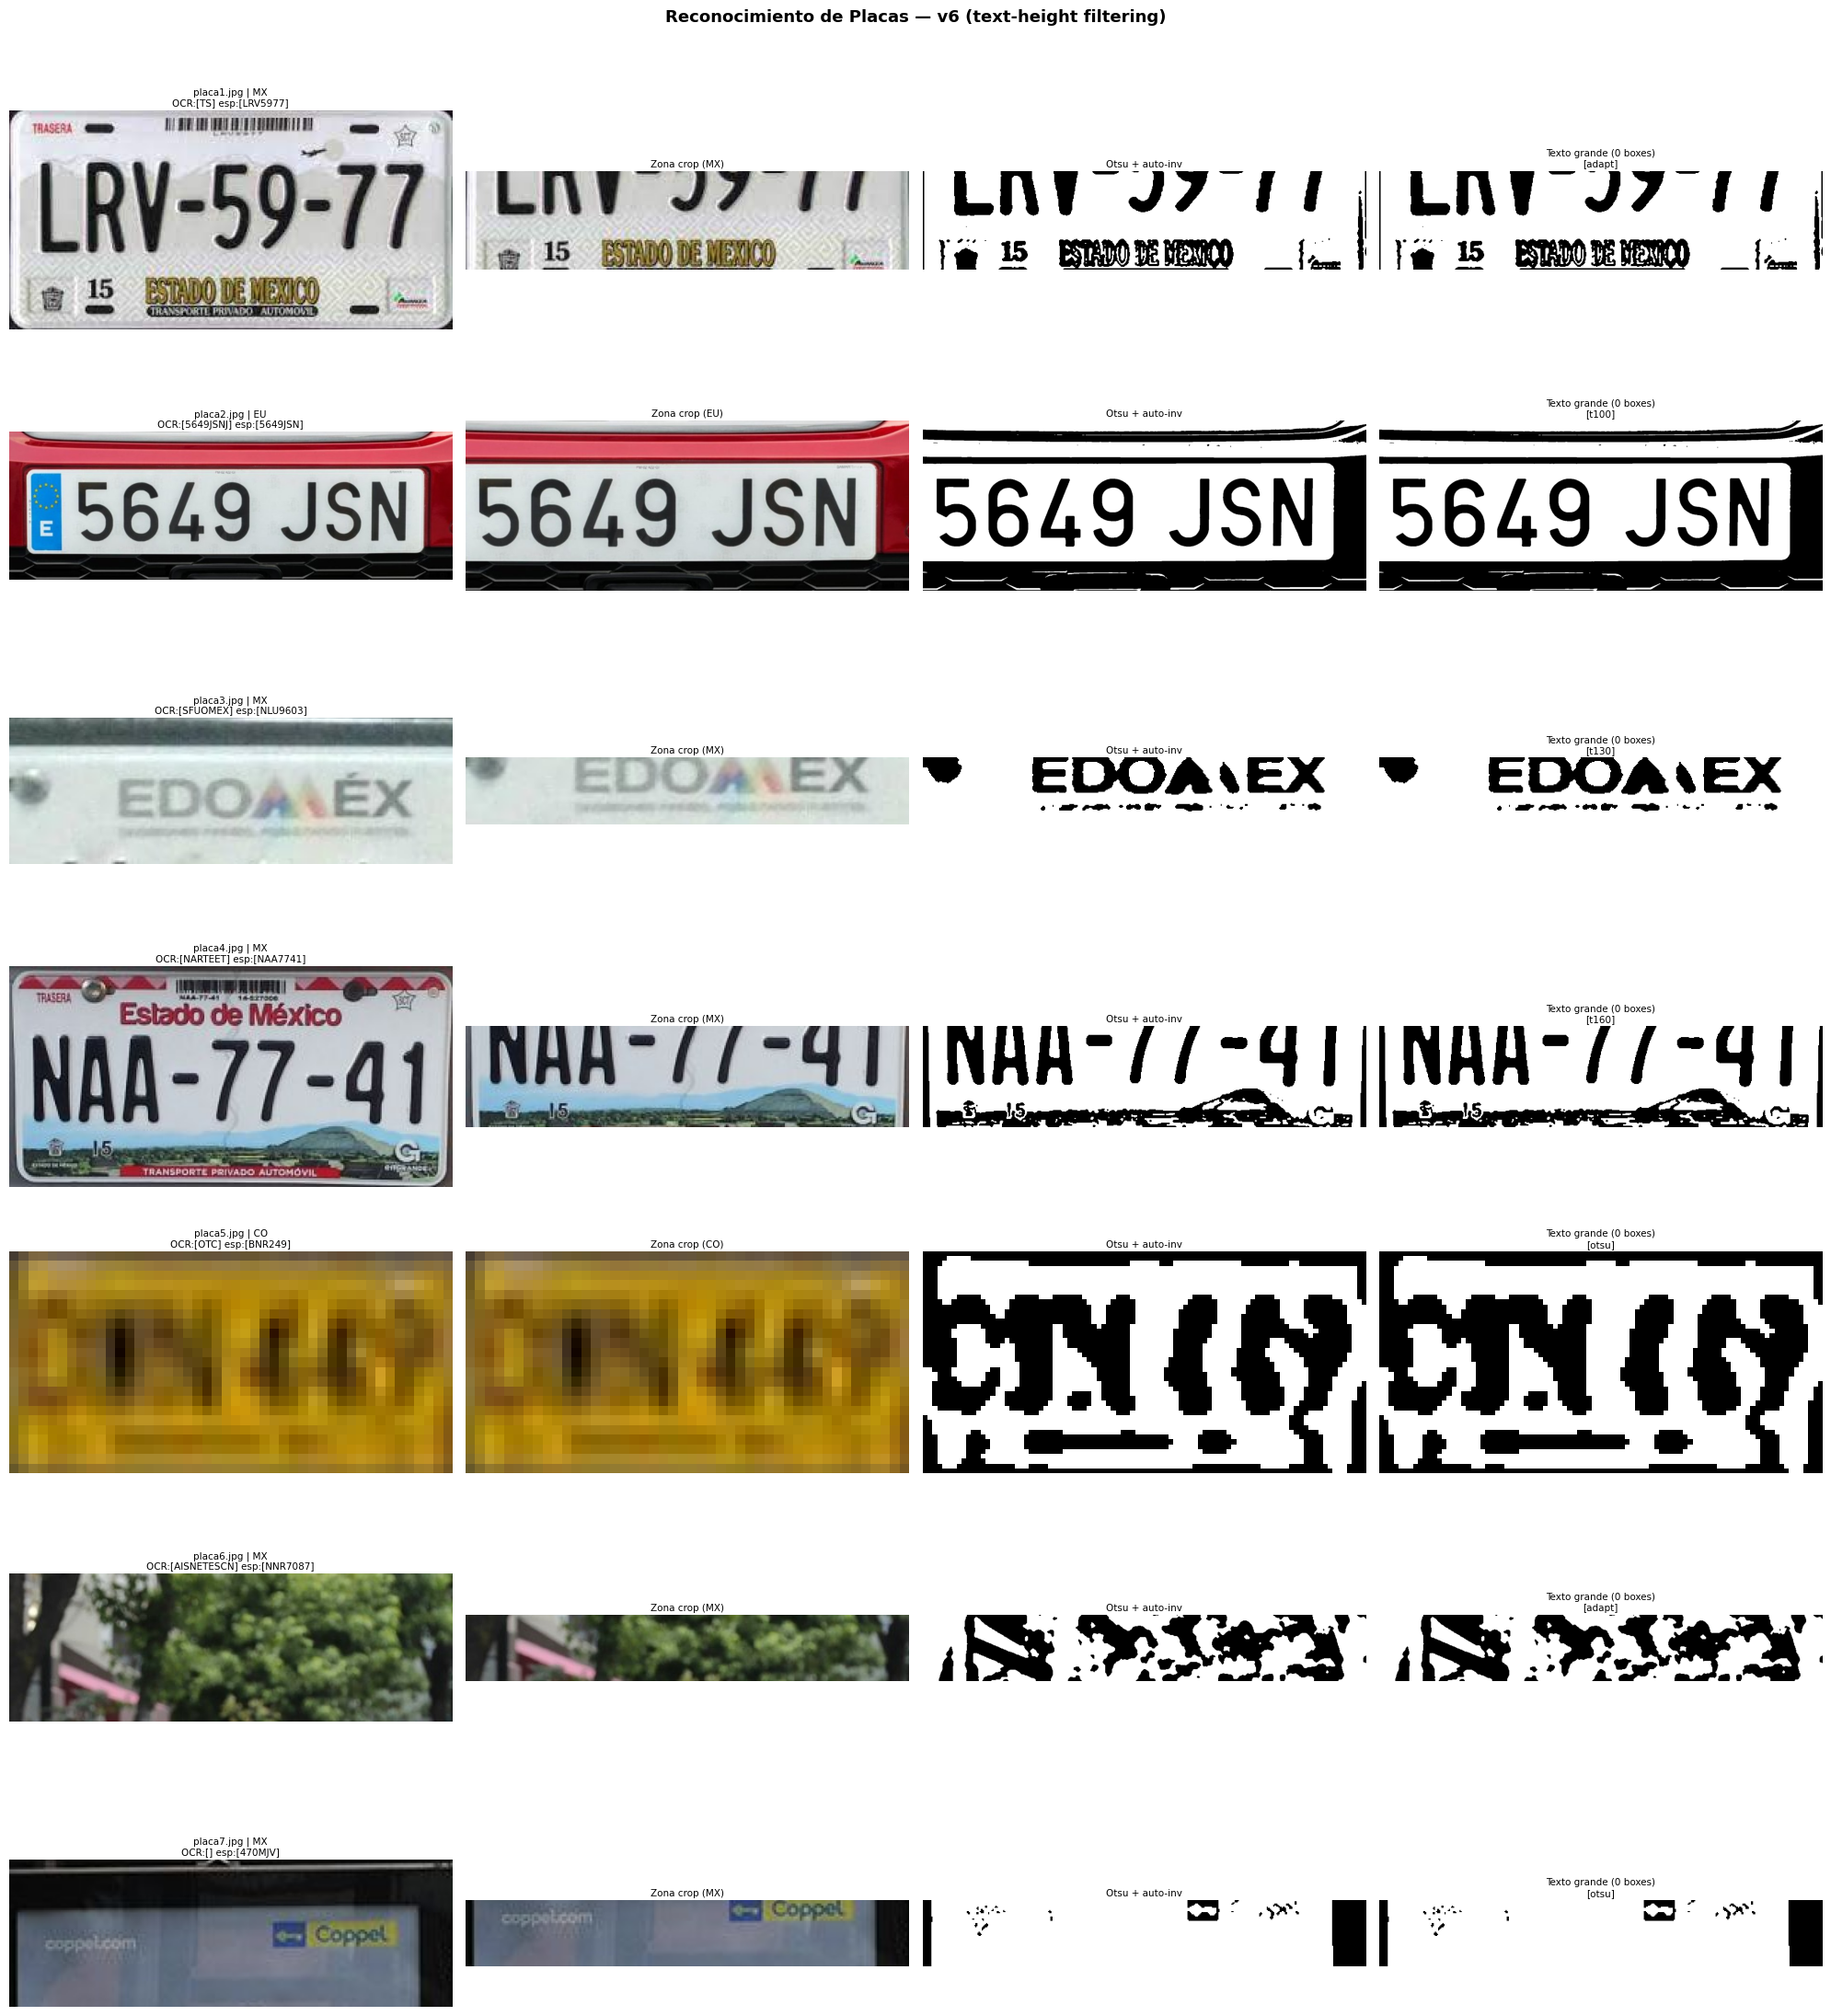

Grilla guardada como output_placas_v6.png ✅


In [12]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Grilla visual con bounding boxes del OCR
# ═══════════════════════════════════════════════════════════════
#
# Col 1 → original + bbox del Haar (verde)
# Col 2 → zona crop (input al OCR)
# Col 3 → Otsu corregido
# Col 4 → Otsu corregido + bounding boxes del texto grande (amarillo)

n    = len(resultados)
fig, axes = plt.subplots(n, 4, figsize=(20, 3.2*n))
if n == 1: axes = [axes]

for fila, r in enumerate(resultados):
    et = r['etapas']
    gt_texto, _ = GROUND_TRUTH.get(r['imagen'], ('?','?'))

    # Col 1: original
    ax = axes[fila][0]
    ax.imshow(et['original'])
    ax.set_title(f"{r['imagen']} | {r['tipo']}\nOCR:[{r['texto']}] esp:[{gt_texto}]",
                 fontsize=7.5, pad=3)
    ax.axis('off')

    # Col 2: zona crop
    ax = axes[fila][1]
    ax.imshow(et['zona'])
    ax.set_title(f'Zona crop ({r["tipo"]})', fontsize=7.5, pad=3)
    ax.axis('off')

    # Col 3: Otsu corregido
    ax = axes[fila][2]
    ax.imshow(et['otsu_corr'], cmap='gray')
    ax.set_title('Otsu + auto-inv', fontsize=7.5, pad=3)
    ax.axis('off')

    # Col 4: Otsu + bounding boxes del texto grande
    ax = axes[fila][3]
    ax.imshow(et['otsu_corr'], cmap='gray')
    for (bx, by, bw, bh) in r['boxes']:
        rect = mpatches.Rectangle((bx, by), bw, bh,
                                   linewidth=2, edgecolor='yellow', facecolor='none')
        ax.add_patch(rect)
    n_boxes = len(r['boxes'])
    ax.set_title(f'Texto grande ({n_boxes} boxes)\n[{r["mejor"]}]', fontsize=7.5, pad=3)
    ax.axis('off')

plt.suptitle('Reconocimiento de Placas — v6 (text-height filtering)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_placas_v6.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grilla guardada como output_placas_v6.png ✅')
